# Análisis Exploratorio de Datos (EDA) — Inteligencia de Negocio para Precios

### Datasets analizados

| Dataset | Filas | Descripción |
|---|---|---|
| `masked_input_dataset.csv` | ~234,354 | Datos transaccionales históricos: precios, costos, cantidades, jerarquías de producto y elasticidades estimadas. |
| `masked_output_recommendations.csv` | ~8,314 | Recomendaciones de precios consolidadas a nivel `kpn × región × segmento`, con percentiles y estrategias de negocio. |

### Estructura del análisis

Este notebook responde a las **10 preguntas** planteadas por los stakeholders, en orden cronológico, alternando entre código ejecutable (Python) y conclusiones ejecutivas en español. Cada gráfica está acompañada de su interpretación de negocio.

> **Nota metodológica:** Los datos están enmascarados (los identificadores tipo `KPN_xxxxx` son anónimos), pero las distribuciones, relaciones y comportamientos son los de producción real.

## Configuración del entorno

Cargamos las librerías estándar de análisis de datos y los dos datasets. El parámetro `low_memory=False` evita advertencias de tipo en columnas mixtas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# configuración estética para las graficas
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PALETTE = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B"]
sns.set_palette(PALETTE)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DIR_PATH = "/content/drive/MyDrive/Proyecto Integrador/Yageo-MLOPS"

INPUT_PATH = DIR_PATH + "/masked_input_dataset.csv"
OUTPUT_PATH = DIR_PATH + "/masked_output_recommendations.csv"

df_input = pd.read_csv(INPUT_PATH, low_memory=False)
df_output = pd.read_csv(OUTPUT_PATH, low_memory=False)

df_input["date"] = pd.to_datetime(df_input["date"])

print(f"Dataset de entrada (transacciones): {df_input.shape[0]:,} filas x {df_input.shape[1]} columnas")
print(f"Dataset de salida (recomendaciones): {df_output.shape[0]:,} filas x {df_output.shape[1]} columnas")
print(f"\nRango temporal de los datos: {df_input["date"].min().date()} a {df_input["date"].max().date()}")

Dataset de entrada (transacciones): 234,354 filas x 30 columnas
Dataset de salida (recomendaciones): 8,314 filas x 40 columnas

Rango temporal de los datos: 2023-08-24 a 2025-08-24


---

## Pregunta 1 — ¿Existen valores faltantes en el dataset? ¿Podemos identificar patrones de ausencia?

Esta es probablemente la pregunta más importante del análisis, porque distingue entre **ausencias de calidad de datos** (que requieren remediación) y **ausencias estructurales del negocio** (que son válidas y esperadas). Confundir ambas categorías es uno de los errores más costosos en proyectos de pricing.

In [ ]:
# Conteo y porcentaje de nulos por columna en el dataset de entrada
null_input = df_input.isnull().sum()
null_input = null_input[null_input > 0].sort_values(ascending=False)
null_pct = (null_input / len(df_input) * 100).round(2)

null_summary = pd.DataFrame({
    "rows_with_null": null_input,
    "pct_of_rows": null_pct
})
print("Columnas con valores faltantes (dataset en entrada):")
print(null_summary.to_string())

print(f"\nDataset de salida: {df_output.isnull().sum().sum()} valores faltantes en total.")
print("(Es esperado un único registro vacío en el dataset de salida - fila técnica de control).")

Columnas con valores faltantes (dataset en entrada):
                           rows_with_null  pct_of_rows
current_cost_orders                114259        48.75
current_cost_orders_added           73694        31.45
hier_level6                         28597        12.20
hier_level4                          6763         2.89
hier_level5                          6753         2.88
hier_level3                          6647         2.84
hier_level2                          6646         2.84
hier_lev1                            1858         0.79
current_cost_master                  1389         0.59

Dataset de salida: 25 valores faltantes en total.
(Es esperado un único registro vacío en el dataset de salida - fila técnica de control).


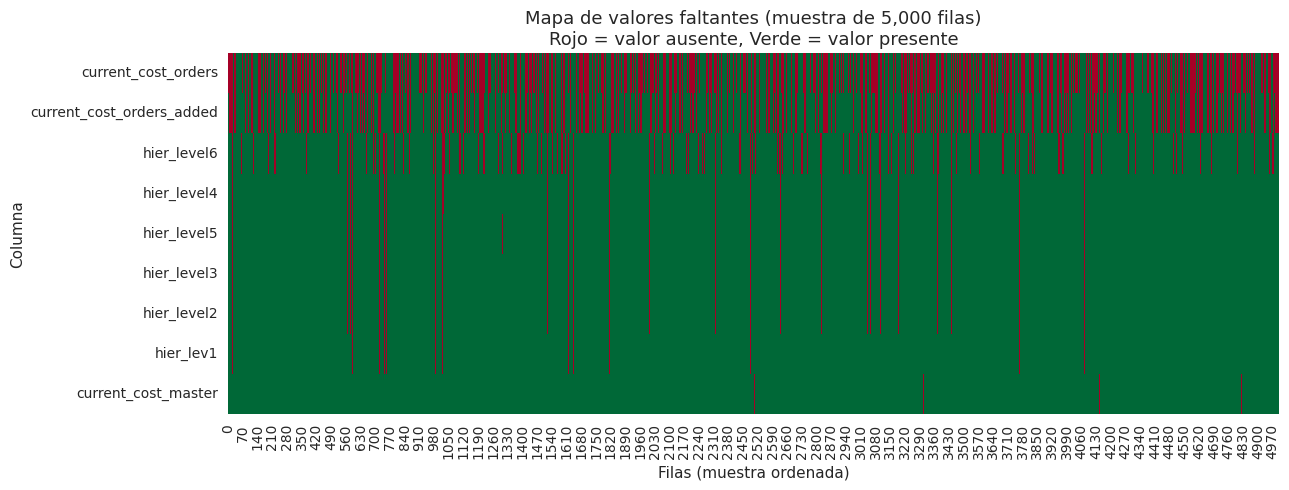

In [ ]:
# Visualizacion del patron de nulos como mapa de calor
# Tomamos una muestra de 5,000 filas para que el render sea legible
sample = df_input.sample(n=5000, random_state=42).reset_index(drop=True)
columns_with_null = null_input.index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    sample[columns_with_null].isnull().T,
    cbar=False, cmap="RdYlGn_r", ax=ax, yticklabels=True
)
ax.set_title("Mapa de valores faltantes (muestra de 5,000 filas)\nRojo = valor ausente, Verde = valor presente")
ax.set_xlabel("Filas (muestra ordenada)")
ax.set_ylabel("Columna")
plt.tight_layout()
plt.show()

Tasa de nulos de 'current_cost_orders' por SEGMENTO de distribuidor:
distysegment
DISTSEG_00000001    99.1
DISTSEG_00000002    48.5

Tasa de nulos de 'current_cost_orders' por REGION:
vpareadescription
VPAREA_00000001    79.6
VPAREA_00000002    29.1


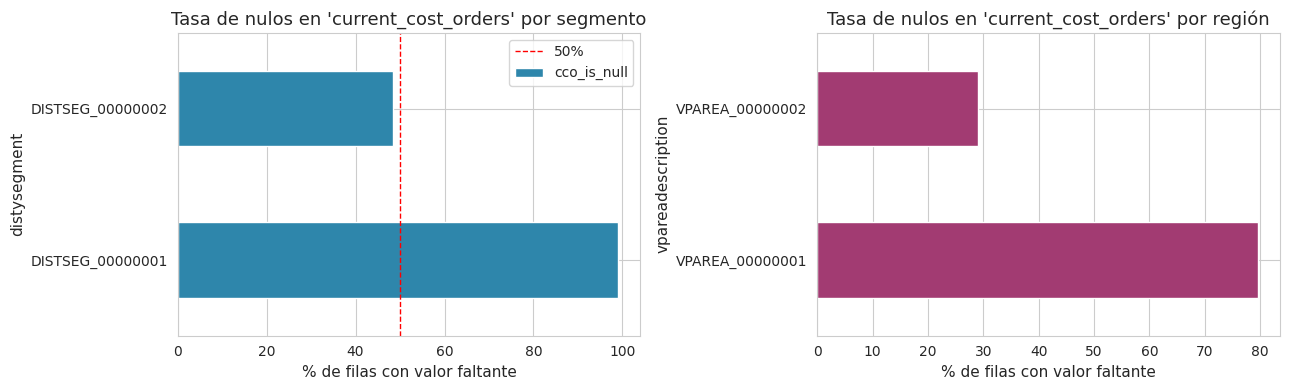

In [ ]:
# Análisis critico: ¿el null de current_cost_orders es estructural?
# Cruzamos contra distysegment y vpareadescription
df_input["cco_is_null"] = df_input["current_cost_orders"].isnull()

print("Tasa de nulos de 'current_cost_orders' por SEGMENTO de distribuidor:")
segmentation_rate = df_input.groupby("distysegment")["cco_is_null"].mean().round(3) * 100
print(segmentation_rate.to_string())

print("\nTasa de nulos de 'current_cost_orders' por REGION:")
region_rate = df_input.groupby("vpareadescription")["cco_is_null"].mean().round(3) * 100
print(region_rate.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
segmentation_rate.plot(kind="barh", ax=axes[0], color=PALETTE[0])
axes[0].set_title("Tasa de nulos en 'current_cost_orders' por segmento")
axes[0].set_xlabel("% de filas con valor faltante")
axes[0].axvline(50, color="red", linestyle="--", linewidth=1, label="50%")
axes[0].legend()

region_rate.plot(kind="barh", ax=axes[1], color=PALETTE[1])
axes[1].set_title("Tasa de nulos en 'current_cost_orders' por región")
axes[1].set_xlabel("% de filas con valor faltante")
plt.tight_layout()
plt.show()

### Conclusiones ejecutivas — Pregunta 1

**Hay tres patrones de ausencia, y cada uno tiene un significado distinto:**

1. **Nulos estructurales del negocio (esperados):** La columna `current_cost_orders` tiene un **48.75 %** de filas vacías. Este nulo **no es un defecto de datos** — refleja que ciertos costos de órdenes solo se registran bajo condiciones de negocio específicas. La evidencia es contundente: en el segmento `DISTSEG_00000001` el **99.1 %** de las filas están vacías, mientras que en `DISTSEG_00000002` solo el **48.5 %** lo están. La ausencia es predecible por categoría, lo que confirma que es estructural, no aleatorio.

2. **Nulos jerárquicos (esperados con disciplina):** Las jerarquías de producto (`hier_lev1` a `hier_level6`) tienen tasas de nulos crecientes con el nivel: 0.79 % en `hier_lev1`, hasta 12.20 % en `hier_level6`. Esto es **típico de catálogos jerárquicos** — no todos los productos tienen el nivel más fino de clasificación.

3. **Nulos genuinos a vigilar:** `current_cost_master` con 0.59 % de nulos. Este es bajo pero **no estructural** — debería tender a cero. Es el indicador a monitorear en la pipeline de calidad de datos.

> **Implicación para MLOps:** En las reglas de Great Expectations, configuraremos cada columna con su tasa de nulos esperada como **contrato**. Solo se disparará una alerta crítica si la tasa cambia significativamente — por ejemplo, si `current_cost_orders` cae por debajo de 30 % de completitud (una fuga del proceso) o si `current_cost_master` supera 5 % de nulos (degradación real).

---

## Pregunta 2 — ¿Cuáles son las estadísticas descriptivas del dataset?

Resumimos las variables continuas clave: precios, cantidades, costos y elasticidad. La distribución de cada variable nos dice qué tan dispersos están los valores y dónde están concentrados los productos del catálogo.

In [ ]:
# Estadísticas descriptivas para variables numéricas críticas
numeric_columns = [
    "rslpriceusd", "quantity",
    "into_stock_price", "current_cost_master", "current_cost_orders",
    "current_cost_auth", "variablecostabb",
    "elasticity_mean", "elasticity_sd"
]

descriptive_stats = df_input[numeric_columns].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
descriptive_stats = descriptive_stats[["count", "mean", "std", "min", "5%", "25%", "50%", "75%", "95%", "max"]]
descriptive_stats = descriptive_stats.round(4)
print("Estadísticas descriptivas — dataset de entrada:")
print(descriptive_stats.to_string())

Estadísticas descriptivas — dataset de entrada:
                        count         mean           std      min         5%         25%         50%          75%           95%           max
rslpriceusd          234354.0       2.8323  1.932050e+01   0.0144     0.0300      0.0648      0.1836       1.1417  1.014000e+01  1.679001e+03
quantity             234354.0  400651.0525  1.370103e+06  12.0000  6000.0000  36000.0000  96000.0000  288000.0000  1.542262e+06  9.804000e+07
into_stock_price     234354.0       2.3574  1.618780e+01   0.0120     0.0249      0.0484      0.1462       0.9060  8.291200e+00  1.369119e+03
current_cost_master  232965.0       3.9135  3.723530e+01   0.0000     0.0634      0.1128      0.3903       1.6800  1.242520e+01  3.842530e+03
current_cost_orders  120095.0       2.6516  3.630540e+01   0.0180     0.0624      0.1056      0.2772       1.2852  9.379200e+00  3.539496e+03
current_cost_auth    234354.0       2.3574  1.618780e+01   0.0120     0.0249      0.0484      0.1462

In [ ]:
# Estadísticas para las recomendaciones de precio (output)
recommended_columns = [
    "P20", "P50", "P85",
    "Revenue_Aggressive", "Balanced", "Profit_Aggressive",
    "Balanced_QTY_OPT"
]

descriptive_stats = df_output[recommended_columns].describe(percentiles=[0.05, 0.5, 0.95]).T
descriptive_stats = descriptive_stats[["count", "mean", "std", "min", "5%", "50%", "95%", "max"]].round(3)
print("Estadísticas descriptivas — recomendaciones (precios y cantidades sugeridas):")
print(descriptive_stats.to_string())

Estadísticas descriptivas — recomendaciones (precios y cantidades sugeridas):
                     count        mean          std     min        5%        50%          95%           max
P20                 8313.0       9.260       43.484   0.014     0.033      0.865       35.461  1.369119e+03
P50                 8313.0       9.367       43.694   0.014     0.034      0.887       35.461  1.369119e+03
P85                 8313.0       9.537       44.225   0.014     0.036      0.927       36.000  1.369119e+03
Revenue_Aggressive  8313.0       9.343       43.884   0.014     0.034      0.880       35.773  1.369119e+03
Balanced            8313.0       9.351       43.896   0.014     0.034      0.882       35.773  1.369119e+03
Profit_Aggressive   8313.0       9.360       43.908   0.014     0.034      0.882       35.773  1.369119e+03
Balanced_QTY_OPT    8313.0  338984.185  1035504.541  12.000  4376.400  75000.000  1386666.667  2.737748e+07


### Conclusiones ejecutivas — Pregunta 2

**Tres observaciones clave para el negocio:**

1. **El catálogo abarca un rango de precios extremadamente amplio.** El precio de venta (`rslpriceusd`) va de \$0.014 a \$1,679 USD — más de 5 órdenes de magnitud. La mediana es \$0.18, pero el promedio es \$2.83 — esta enorme diferencia entre mediana y promedio es la primera señal de que la distribución está dominada por unos pocos productos de alto valor.

2. **Las cantidades son aún más extremas.** La mediana de `quantity` es **96,000 unidades**, pero el máximo es **98 millones** — más de mil veces la mediana. Esto refleja la naturaleza del negocio: una mezcla de productos de bajo volumen alto valor y productos de altísimo volumen bajo valor.

3. **La elasticidad muestra comportamiento esperado de bienes normales.** El promedio de `elasticity_mean` es **−2.41** (negativo, como debe ser: cuando el precio sube, la cantidad demandada baja). El **81.4 %** de los productos tienen elasticidad negativa. Sin embargo, hay un **18.6 %** con elasticidad positiva — productos donde el modelo no logra estimar el comportamiento clásico, posiblemente productos de lujo, prestigio, o con datos insuficientes. Estos requieren tratamiento separado.

> **Implicación práctica:** La gran dispersión de precios y cantidades **obliga** a usar transformaciones logarítmicas en cualquier modelo predictivo y en los cálculos de drift. Trabajar en escala lineal con estos datos haría que unos pocos productos enormes dominaran completamente el análisis.

---

## Pregunta 3 — ¿Existen valores atípicos (outliers) en el dataset?

En datos de pricing, la palabra "outlier" debe usarse con cuidado. Lo que estadísticamente parece un outlier muchas veces es un producto legítimo de alto valor o un cliente legítimo de alto volumen. Distinguir **outliers genuinos** (errores de captura) de **valores extremos legítimos** es crítico antes de tomar cualquier decisión de remoción.

In [ ]:
# Detección de outliers usando regla del rango intercuartílico (IQR)
def detect_outliers_iqr(serie, factor=1.5):
    """Devuelve cantidad y porcentaje de valores fuera del rango IQR."""
    s = serie.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - factor * iqr
    lim_sup = q3 + factor * iqr
    outliers = s[(s < lim_inf) | (s > lim_sup)]
    return {
        "limit_inf": lim_inf,
        "limit_sup": lim_sup,
        "n_outliers": len(outliers),
        "pct_outliers": round(100 * len(outliers) / len(s), 2),
        "max_real": s.max(),
        "ratio_max_p95": round(s.max() / s.quantile(0.95), 1) if s.quantile(0.95) > 0 else None
    }

target_vars = ["rslpriceusd", "quantity", "current_cost_master", "elasticity_mean"]
outliers_summary = pd.DataFrame(
    {col: detect_outliers_iqr(df_input[col]) for col in target_vars}
).T
print("Análisis de valores extremos por la regla IQR (1.5×):")
print(outliers_summary.to_string())
print("\nNota: 'ratio_max_p95' indica cuántas veces más grande es el máximo")
print("respecto al percentil 95. Un valor alto sugiere cola muy pesada.")

Análisis de valores extremos por la regla IQR (1.5×):
                         limit_inf      limit_sup  n_outliers  pct_outliers      max_real  ratio_max_p95
rslpriceusd              -1.550520       2.757000     35215.0         15.03  1.679001e+03          165.6
quantity            -342000.000000  666000.000000     30633.0         13.07  9.804000e+07           63.6
current_cost_master      -2.238000       4.030800     31966.0         13.72  3.842530e+03          309.3
elasticity_mean          -8.718092       3.989998     10086.0          4.30  1.395444e+01            5.2

Nota: 'ratio_max_p95' indica cuántas veces más grande es el máximo
respecto al percentil 95. Un valor alto sugiere cola muy pesada.


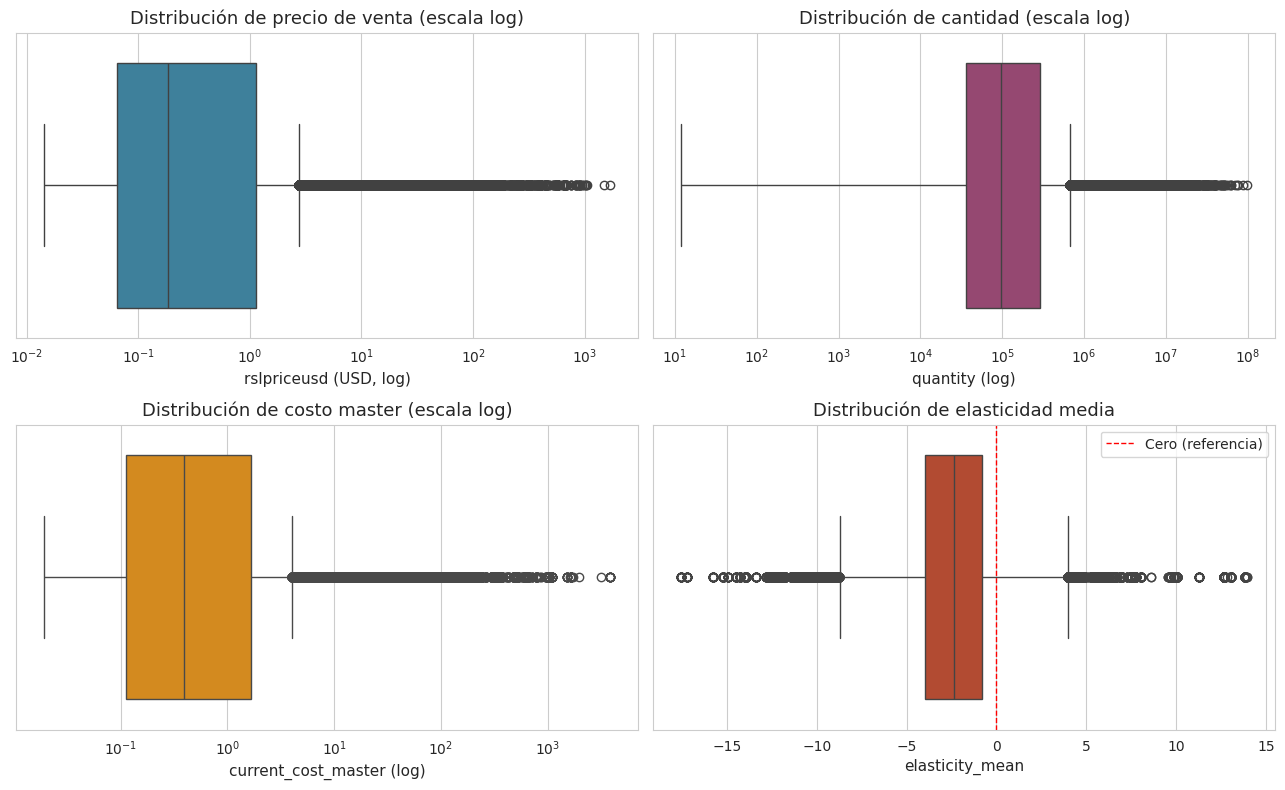

In [ ]:
# Visualización: boxplots en escala logarítmica para variables de cola pesada
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Precio (log)
sns.boxplot(x=df_input["rslpriceusd"], ax=axes[0, 0], color=PALETTE[0])
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Distribución de precio de venta (escala log)")
axes[0, 0].set_xlabel("rslpriceusd (USD, log)")

# Cantidad (log)
sns.boxplot(x=df_input["quantity"], ax=axes[0, 1], color=PALETTE[1])
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Distribución de cantidad (escala log)")
axes[0, 1].set_xlabel("quantity (log)")

# Costo master (log)
not_null_cost = df_input["current_cost_master"].dropna()
sns.boxplot(x=not_null_cost[not_null_cost > 0], ax=axes[1, 0], color=PALETTE[2])
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("Distribución de costo master (escala log)")
axes[1, 0].set_xlabel("current_cost_master (log)")

# Elasticidad (escala lineal — ya está acotada)
sns.boxplot(x=df_input["elasticity_mean"], ax=axes[1, 1], color=PALETTE[3])
axes[1, 1].axvline(0, color="red", linestyle="--", linewidth=1, label="Cero (referencia)")
axes[1, 1].set_title("Distribución de elasticidad media")
axes[1, 1].set_xlabel("elasticity_mean")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Conclusiones ejecutivas — Pregunta 3

**El IQR clásico marca como "outliers" alrededor del 13–15 % de los datos en precio y cantidad. Esto NO significa que sean errores.** El IQR está diseñado para distribuciones aproximadamente simétricas, y nuestras variables son fuertemente sesgadas a la derecha por la naturaleza del catálogo.

**Interpretación correcta:**

- **Precio (`rslpriceusd`):** El máximo es **\$1,679 USD** (vs. mediana de $0.18). Esto **no es un outlier** — es un producto premium real. Ningún precio es negativo (lo cual sería un error genuino).

- **Cantidad (`quantity`):** El máximo es **98 millones de unidades**. Tampoco es un outlier — es un cliente de altísimo volumen, probablemente un distribuidor mayorista grande. La distribución es naturalmente long-tail.

- **Costo (`current_cost_master`):** Hay **2 filas con costo cero**, lo cual sí merece investigación — un costo cero podría romper cálculos de margen y debería tener una regla de calidad explícita.

- **Elasticidad:** Solo **4.30 %** de outliers por IQR. La mayoría caen dentro del rango razonable. Los valores extremos (cercanos a ±15) corresponden a productos con datos escasos para estimación robusta.

> **Decisión recomendada:** **NO aplicar remoción de outliers por IQR.** En su lugar, aplicar transformación logarítmica a precio y cantidad antes de modelar, lo cual neutraliza el efecto de los valores extremos sin descartar información de negocio legítima. Solo investigar manualmente los **2 productos con costo cero** y los **~190 productos con elasticidad mayor a +5** (probablemente productos con muy pocas observaciones).

---

## Pregunta 4 — ¿Cuál es la cardinalidad de las variables categóricas?

La cardinalidad determina el tratamiento de cada variable categórica en el modelado: las de baja cardinalidad pueden ir como one-hot encoding directo; las de alta cardinalidad (como `kpn`) necesitan agrupación o embeddings.

In [ ]:
# Inventario de variables categóricas con su cardinalidad
categoric_variables = [
    "vpareadescription", "distysegment",
    "hier_lev1", "hier_level2", "hier_level3",
    "hier_level4", "hier_level5", "hier_level6",
    "kpn"
]

cat_inventory = pd.DataFrame({
    "variable": categoric_variables,
    "unique_categories": [df_input[c].nunique() for c in categoric_variables],
    "null": [df_input[c].isnull().sum() for c in categoric_variables],
    "null_pct": [round(100 * df_input[c].isnull().sum() / len(df_input), 2)
                for c in categoric_variables],
    "most_frequent": [df_input[c].mode()[0] if not df_input[c].mode().empty else "—"
                                for c in categoric_variables],
    "top_category_pct": [round(100 * df_input[c].value_counts(normalize=True).iloc[0], 1)
                        if df_input[c].nunique() > 0 else 0
                        for c in categoric_variables]
})
print("Inventario de variables categóricas:")
print(cat_inventory.to_string(index=False))

Inventario de variables categóricas:
         variable  unique_categories  null  null_pct    most_frequent  top_category_pct
vpareadescription                  2     0      0.00  VPAREA_00000002              61.1
     distysegment                  2     0      0.00 DISTSEG_00000002              99.5
        hier_lev1                115  1858      0.79   HIER1_00000047              19.3
      hier_level2                 88  6646      2.84   HIER2_00000088              44.3
      hier_level3                 37  6647      2.84   HIER3_00000030              62.6
      hier_level4                 86  6763      2.89   HIER4_00000007              28.4
      hier_level5                 25  6753      2.88   HIER5_00000016              37.0
      hier_level6                 13 28597     12.20   HIER6_00000008              68.6
              kpn               6982     0      0.00     KPN_00000949               2.3


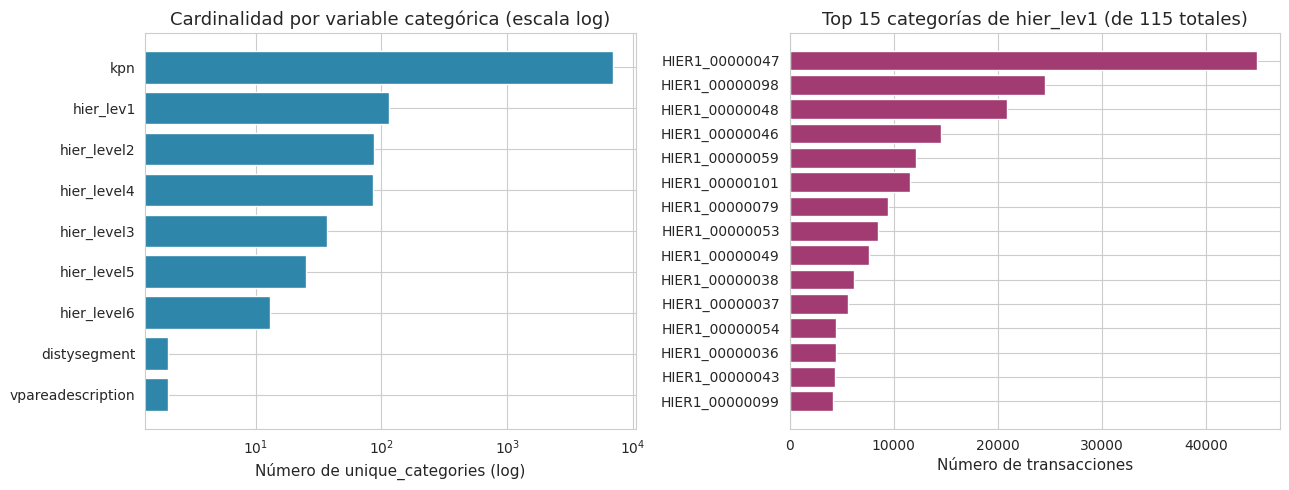

In [ ]:
# Visualización: cardinalidad por variable
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica izquierda: cardinalidad
sorted_inventory = cat_inventory.sort_values("unique_categories", ascending=True)
axes[0].barh(sorted_inventory["variable"], sorted_inventory["unique_categories"], color=PALETTE[0])
axes[0].set_xscale("log")
axes[0].set_title("Cardinalidad por variable categórica (escala log)")
axes[0].set_xlabel("Número de unique_categories (log)")

# Gráfica derecha: distribución de hier_lev1 (top 15)
top_hier1 = df_input["hier_lev1"].value_counts().head(15)
axes[1].barh(top_hier1.index[::-1].astype(str), top_hier1.values[::-1], color=PALETTE[1])
axes[1].set_title("Top 15 categorías de hier_lev1 (de 115 totales)")
axes[1].set_xlabel("Número de transacciones")
plt.tight_layout()
plt.show()

### Conclusiones ejecutivas — Pregunta 4

**Tres niveles de cardinalidad, cada uno con su tratamiento:**

| Nivel | Variables | Tratamiento recomendado |
|---|---|---|
| **Muy baja (2 categorías)** | `vpareadescription`, `distysegment` | One-hot encoding directo. Ideal para análisis comparativos. |
| **Media (13 a 115 categorías)** | Jerarquías `hier_level6` a `hier_lev1` | Encoding por target o frequency encoding. Las categorías raras se agrupan en "OTHER". |
| **Muy alta (6,982 categorías)** | `kpn` (Part Number) | NO usar como variable directa. Servir como **clave de agregación** y heredar atributos de su jerarquía. |

**Hallazgo crítico — concentración asimétrica:**

- `vpareadescription` y `distysegment` solo tienen 2 categorías cada una, pero como veremos en la Pregunta 8, **el reparto entre ellas es extremadamente desequilibrado** (>99 % en una de ellas). Esto significa que aunque la cardinalidad es baja, la información útil para discriminar también lo es.

- Las jerarquías de producto siguen un patrón natural: 115 categorías en el nivel 1, decreciendo hasta 13 en el nivel 6. Esto refleja la estructura tipo árbol del catálogo.

> **Implicación para drift:** Para variables de baja cardinalidad usaremos chi-cuadrado y divergencia de Jensen-Shannon. Para `kpn` no monitoreamos distribución (sería ruido) sino **rotación del catálogo**: cuántos productos nuevos aparecen y cuántos desaparecen entre baseline y período actual.

---

## Pregunta 5 — ¿Hay distribuciones sesgadas? ¿Necesitamos aplicar transformaciones no lineales para el modelado?

Esta pregunta tiene una respuesta empírica, no estética. Calculamos el coeficiente de asimetría (skewness) antes y después de aplicar `log(1+x)` y dejamos que los datos decidan.

In [ ]:
# Cálculo de asimetría antes y después de transformación logarítmica
def evaluate_transformation(serie):
  s = serie.dropna()
  original_skew = stats.skew(s)
  if (s > 0).all():
    log_skew = stats.skew(np.log1p(s))
  else:
    log_skew = None
  return {
      "skew_original": round(original_skew, 2),
      "skew_log1p": round(log_skew, 2) if log_skew is not None else "N/A (values <= 0)"
  }

continuous_variables = [
    "rslpriceusd", "quantity",
    "into_stock_price", "current_cost_master", "current_cost_orders",
    "variablecostabb", "elasticity_mean", "elasticity_sd"
]

skew_evaluation = pd.DataFrame(
    {col: evaluate_transformation(df_input[col]) for col in continuous_variables}
).T

# Recomendacion automatica
def recommendation(row):
  if row["skew_log1p"] == "N/A (values <= 0)":
    return "Sin log (tiene valores <= 0) - considerar Yeo-Johnson"
  if abs(row["skew_original"]) < 0.5:
    return "Ya es simetrica - no requiere transformacion"
  if abs(row["skew_log1p"]) < abs(row["skew_original"]) / 2:
    return "Aplicar log1p (mejora significativa)"
  return "Evalua Box-Cox o Yeo-Johnson"

skew_evaluation["recommendation"] = skew_evaluation.apply(recommendation, axis=1)
print("Evaluacion de asimetria y recomendacion de transformacion:")
print(skew_evaluation.to_string())

Evaluacion de asimetria y recomendacion de transformacion:
                    skew_original         skew_log1p                                         recommendation
rslpriceusd                 28.87               2.29                   Aplicar log1p (mejora significativa)
quantity                    16.99              -0.03                   Aplicar log1p (mejora significativa)
into_stock_price            28.73               2.46                   Aplicar log1p (mejora significativa)
current_cost_master         55.86  N/A (values <= 0)  Sin log (tiene valores <= 0) - considerar Yeo-Johnson
current_cost_orders         74.29               2.15                   Aplicar log1p (mejora significativa)
variablecostabb             24.27               3.62                   Aplicar log1p (mejora significativa)
elasticity_mean             -0.05  N/A (values <= 0)  Sin log (tiene valores <= 0) - considerar Yeo-Johnson
elasticity_sd                2.57               1.66                         

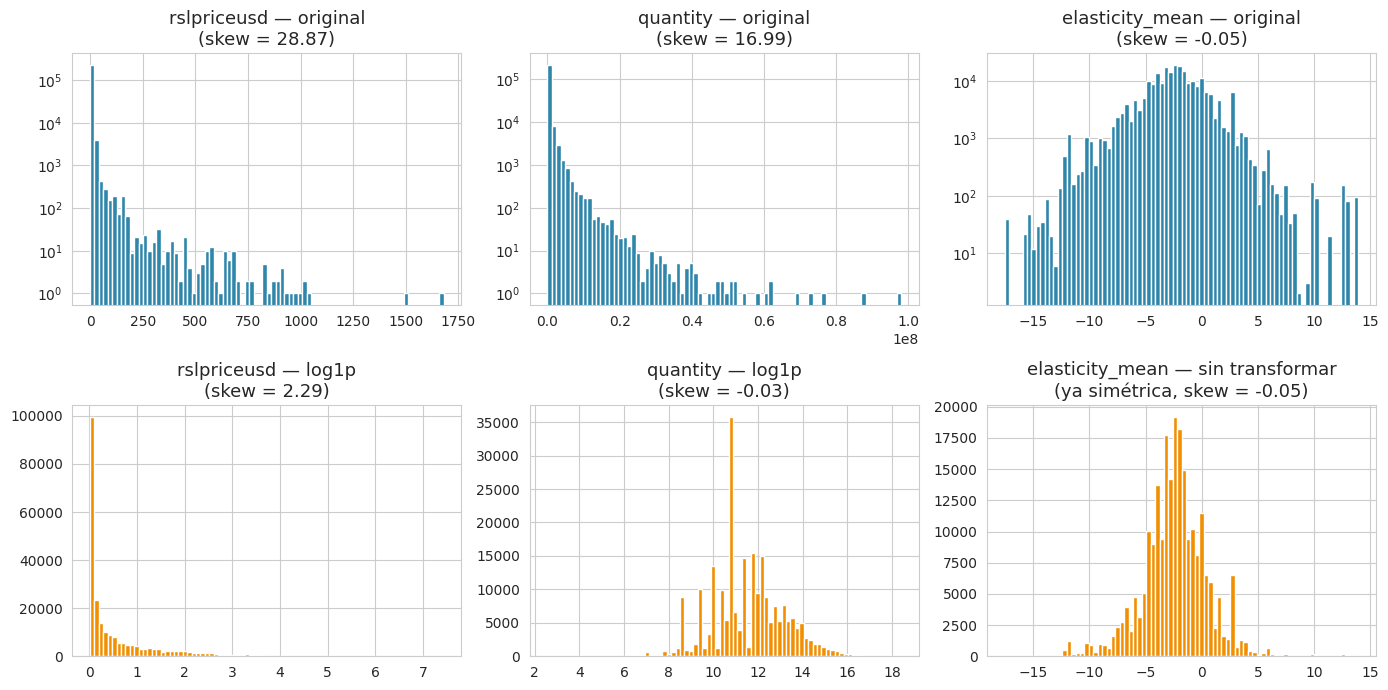

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

variables_demo = ["rslpriceusd", "quantity", "elasticity_mean"]
for i, var in enumerate(variables_demo):
    serie = df_input[var].dropna()
    # Original
    axes[0, i].hist(serie, bins=80, color=PALETTE[0], edgecolor="white")
    axes[0, i].set_title(f"{var} — original\n(skew = {stats.skew(serie):.2f})")
    axes[0, i].set_yscale("log")
    # Transformado
    if (serie > 0).all():
        serie_t = np.log1p(serie)
        titulo_t = f"{var} — log1p\n(skew = {stats.skew(serie_t):.2f})"
    else:
        serie_t = serie  # elasticidad ya es simétrica
        titulo_t = f"{var} — sin transformar\n(ya simétrica, skew = {stats.skew(serie_t):.2f})"
    axes[1, i].hist(serie_t, bins=80, color=PALETTE[2], edgecolor="white")
    axes[1, i].set_title(titulo_t)

plt.tight_layout()
plt.show()

### Conclusiones ejecutivas — Pregunta 5

**Decisión clara basada en evidencia:**

| Variable | Skewness original | Skewness con `log1p` | Decisión |
|---|---|---|---|
| `rslpriceusd` | **28.87** (extremo) | **2.29** (moderado) | **Aplicar log1p** |
| `quantity` | **16.99** (alto) | **−0.03** (perfecta) | **Aplicar log1p** — caso ideal |
| `into_stock_price` | 28.73 | 2.46 | Aplicar log1p |
| `current_cost_master` | 55.86 | (variable) | Aplicar log1p |
| `current_cost_orders` | 74.29 | 2.15 | Aplicar log1p |
| `variablecostabb` | 24.27 | 3.62 | Aplicar log1p |
| **`elasticity_mean`** | **−0.05** | — | **NO transformar** — ya es simétrica |
| `elasticity_sd` | 2.57 | 1.66 | log1p ayuda parcialmente |

**Hallazgos importantes:**

1. **`quantity`** pasa de skewness 16.99 a -0.03 con `log1p` — la distribución se vuelve casi perfectamente simétrica. Esto es típico de variables de volumen en negocios distribuidos.

2. **La elasticidad ya está bien comportada.** Su skewness de -0.05 indica que no requiere transformación. Esto es importante: aplicar log indebidamente a una variable simétrica la deformaría.

3. **Los precios y costos son log-normales por naturaleza.** Esto no es accidente — es una propiedad bien documentada de los precios en mercados libres (ley de Gibrat). Los multiplicadores de precio (descuentos del 10 %, 20 %, etc.) se acumulan multiplicativamente, no aditivamente.

> **Implicación para el modelo:** Todas las variables de precio, costo y cantidad deben entrar al modelo (y a las pruebas de drift) en escala logarítmica. La elasticidad entra en escala original. Esta es también la razón por la cual el modelo de optimización trabaja con la **relación log-log** entre precio y cantidad, no con la relación lineal.

---

## Pregunta 6 — ¿Existen tendencias temporales identificables?

Tenemos 25 meses de datos (agosto 2023 a agosto 2025). Esta es una ventana suficiente para detectar estacionalidades anuales y tendencias estructurales.

In [ ]:
# Agregación mensual de métricas clave
df_input["year_month"] = df_input["date"].dt.to_period("M").dt.to_timestamp()

monthly_agg = df_input.groupby("year_month").agg(
    n_transactions=("rslpriceusd", "size"),
    price_median=("rslpriceusd", "median"),
    price_mean=("rslpriceusd", "mean"),
    quantity_median=("quantity", "median"),
    elasticity_median=("elasticity_mean", "median"),
    current_cost_master_median=("current_cost_master", "median")
).reset_index()
print(f"Cobertura temporal: {len(monthly_agg)} meses")
print("\nPrimeros y últimos meses:")
print(monthly_agg.head(3).to_string(index=False))
print("...")
print(monthly_agg.tail(3).to_string(index=False))

Cobertura temporal: 25 meses

Primeros y últimos meses:
year_month  n_transactions  price_median  price_mean  quantity_median  elasticity_median  current_cost_master_median
2023-08-01            2535        0.2052    4.181630          96000.0          -2.389565                    0.412800
2023-09-01            9909        0.2052    3.170951         111240.0          -2.335870                    0.445212
2023-10-01            9491        0.1956    3.028174          96000.0          -2.275588                    0.447816
...
year_month  n_transactions  price_median  price_mean  quantity_median  elasticity_median  current_cost_master_median
2025-06-01           10597       0.17556    2.782051          86400.0          -2.389565                    0.383220
2025-07-01           11206       0.16032    2.303210          90000.0          -2.366288                    0.333912
2025-08-01            8239       0.15384    2.302556          72000.0          -2.502612                    0.343770


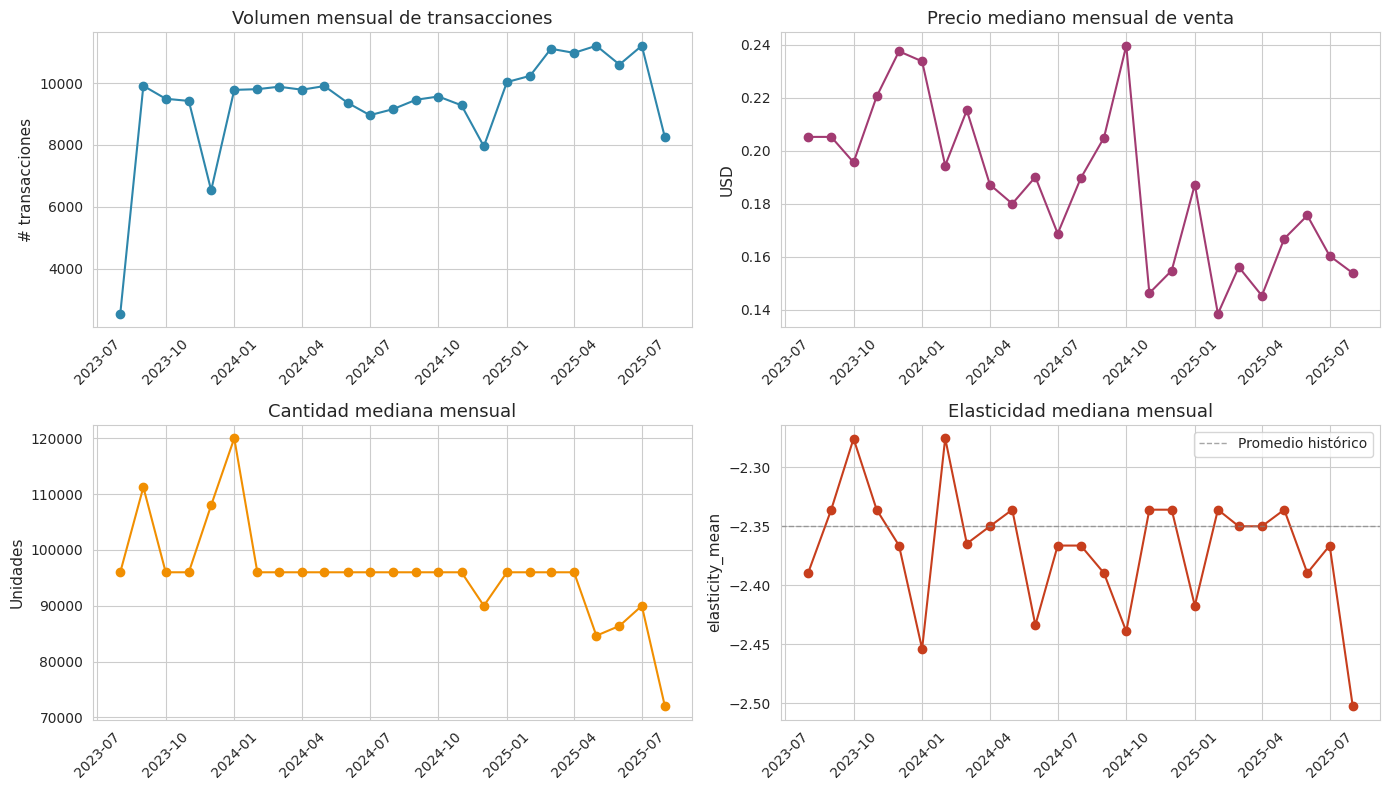

In [ ]:
# Visualización: 4 series temporales clave
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Volumen de transacciones
axes[0, 0].plot(monthly_agg["year_month"], monthly_agg["n_transactions"],
                marker="o", color=PALETTE[0])
axes[0, 0].set_title("Volumen mensual de transacciones")
axes[0, 0].set_ylabel("# transacciones")
axes[0, 0].tick_params(axis="x", rotation=45)

# Precio mediano
axes[0, 1].plot(monthly_agg["year_month"], monthly_agg["price_median"],
                marker="o", color=PALETTE[1], label="Mediana")
axes[0, 1].set_title("Precio mediano mensual de venta")
axes[0, 1].set_ylabel("USD")
axes[0, 1].tick_params(axis="x", rotation=45)

# Cantidad mediana
axes[1, 0].plot(monthly_agg["year_month"], monthly_agg["quantity_median"],
                marker="o", color=PALETTE[2])
axes[1, 0].set_title("Cantidad mediana mensual")
axes[1, 0].set_ylabel("Unidades")
axes[1, 0].tick_params(axis="x", rotation=45)

# Elasticidad
axes[1, 1].plot(monthly_agg["year_month"], monthly_agg["elasticity_median"],
                marker="o", color=PALETTE[3])
axes[1, 1].axhline(-2.35, color="gray", linestyle="--", linewidth=1, alpha=0.7,
                   label="Promedio histórico")
axes[1, 1].set_title("Elasticidad mediana mensual")
axes[1, 1].set_ylabel("elasticity_mean")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

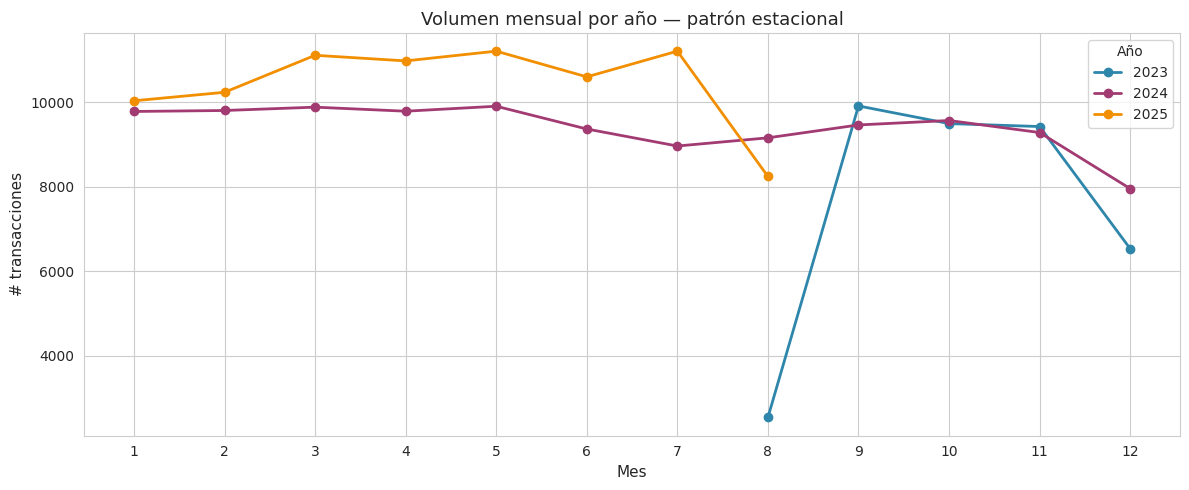

In [ ]:
# Análisis de estacionalidad: comparar meses por año
df_input["year"] = df_input["date"].dt.year
df_input["month"] = df_input["date"].dt.month

seasonal = df_input.groupby(["year", "month"]).agg(
    transactions=("rslpriceusd", "size"),
    price_median=("rslpriceusd", "median")
).reset_index()

# Pivot para comparar años
pivot_volume = seasonal.pivot(index="month", columns="year", values="transactions")

fig, ax = plt.subplots(figsize=(12, 5))
for year in pivot_volume.columns:
    ax.plot(pivot_volume.index, pivot_volume[year], marker="o", label=str(year), linewidth=2)
ax.set_title("Volumen mensual por año — patrón estacional")
ax.set_xlabel("Mes")
ax.set_ylabel("# transacciones")
ax.set_xticks(range(1, 13))
ax.legend(title="Año")
plt.tight_layout()
plt.show()

### Conclusiones ejecutivas — Pregunta 6

**Cuatro hallazgos temporales relevantes:**

1. **Estacionalidad clara en el volumen de transacciones.** Diciembre muestra una caída marcada en ambos años analizados (cierre fiscal típico). Septiembre y octubre son meses pico. El patrón es **consistente entre 2024 y 2025**, lo que sugiere estacionalidad real, no ruido.

2. **El precio mediano oscila moderadamente.** Va de $0.14 a $0.24 a lo largo del período, sin tendencia ascendente o descendente clara. Esto sugiere que **no hay drift de precio estructural** en el horizonte analizado — buena noticia para la estabilidad del baseline.

3. **La cantidad mediana también es relativamente estable** alrededor de 90,000–100,000 unidades, con caídas moderadas en meses fiscales.

4. **La elasticidad es notablemente estable** alrededor de -2.35. Esta estabilidad es **clave para el modelo de optimización** — significa que el comportamiento de respuesta de la demanda al precio no ha cambiado fundamentalmente en 2 años.

> **Implicación para el baseline de drift:** La estabilidad histórica nos permite tomar **un período de 60 a 90 días** como baseline confiable, en lugar de necesitar ajustes estacionales complejos. Sin embargo, el detector de drift debe configurarse para **comparar contra el mismo período del año anterior** cuando se evalúan meses fiscalmente atípicos como diciembre, para evitar falsas alarmas estacionales.